In [1]:
import os
os.environ["CUDA_VISIBLE_DEVICES"] = "2"  # change to "0" if only 1 GPU

import numpy as np
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader, TensorDataset
from sklearn.metrics import accuracy_score, f1_score, roc_auc_score
from scipy.interpolate import interp1d
from sklearn.metrics import roc_curve
import torchvision.models as models
from torchvision.models import resnet50, ResNet50_Weights  # ← updated
import torchaudio
import whisper
import matplotlib.pyplot as plt

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Device : {device}")
print(f"GPU    : {torch.cuda.get_device_name(0)}")

# ── Tunable Parameters ─────────────────────────────────────────────────
CNN_EPOCHS      = 20
CNN_LR          = 1e-3
CNN_PATIENCE    = 5
CNN_BATCH       = 32

RESNET_EPOCHS   = 10
RESNET_LR       = 1e-4
RESNET_PATIENCE = 3
RESNET_BATCH    = 32

WHISPER_EPOCHS   = 20
WHISPER_LR       = 1e-3
WHISPER_PATIENCE = 5
WHISPER_BATCH    = 256

print("\n── Config ────────────────────────────────────────────")
print(f"CNN    : epochs={CNN_EPOCHS}  lr={CNN_LR}  patience={CNN_PATIENCE}")
print(f"ResNet : epochs={RESNET_EPOCHS}  lr={RESNET_LR}  patience={RESNET_PATIENCE}")
print(f"Whisper: epochs={WHISPER_EPOCHS}  lr={WHISPER_LR}  patience={WHISPER_PATIENCE}")
print("──────────────────────────────────────────────────────")

Device : cuda
GPU    : NVIDIA A100-SXM4-40GB

── Config ────────────────────────────────────────────
CNN    : epochs=20  lr=0.001  patience=5
ResNet : epochs=10  lr=0.0001  patience=3
Whisper: epochs=20  lr=0.001  patience=5
──────────────────────────────────────────────────────


In [2]:
class MultiSpectrogramDataset(Dataset):
    """
    Loads 3-branch spectrogram tensors (STFT, CQT, Wavelet)
    each of shape (3, 64, 64) — original + delta + delta-delta channels
    """
    def __init__(self, data_dir):
        self.data_dir = data_dir
        all_files = os.listdir(data_dir)
        self.base_names = sorted(
            f.replace("_stft.pt", "")
            for f in all_files if f.endswith("_stft.pt")
        )
        print(f"[{data_dir}]  segments: {len(self.base_names)}")

    def __len__(self):
        return len(self.base_names)

    def __getitem__(self, idx):
        base = self.base_names[idx]
        d    = self.data_dir

        stft = torch.load(os.path.join(d, f"{base}_stft.pt"), weights_only=True)
        cqt  = torch.load(os.path.join(d, f"{base}_cqt.pt"),  weights_only=True)
        wav  = torch.load(os.path.join(d, f"{base}_wav.pt"),  weights_only=True)

        label = int(base.split("_label")[1].split("_")[0])

        return (stft, cqt, wav), label


# Load all 3 splits
train_ds = MultiSpectrogramDataset("processed/train")
dev_ds   = MultiSpectrogramDataset("processed/dev")
eval_ds  = MultiSpectrogramDataset("processed/eval")

# DataLoaders
train_loader = DataLoader(train_ds, batch_size=CNN_BATCH,
                          shuffle=True,  num_workers=2, pin_memory=True)
dev_loader   = DataLoader(dev_ds,   batch_size=CNN_BATCH,
                          shuffle=False, num_workers=2, pin_memory=True)
eval_loader  = DataLoader(eval_ds,  batch_size=CNN_BATCH,
                          shuffle=False, num_workers=2, pin_memory=True)

print("\nDataLoaders ready ✅")
print(f"Train : {len(train_ds):,} segments")
print(f"Dev   : {len(dev_ds):,} segments")
print(f"Eval  : {len(eval_ds):,} segments")

# Extract unique file IDs from eval — needed for file-level aggregation later
eval_file_ids = np.array([
    "_".join(base.split("_seg")[0].split("_"))
    for base in eval_ds.base_names
])

seen = set()
unique_eval_file_ids = []
for fid in eval_file_ids:
    if fid not in seen:
        seen.add(fid)
        unique_eval_file_ids.append(fid)

print(f"Unique eval files : {len(unique_eval_file_ids):,}")

[processed/train]  segments: 56100
[processed/dev]  segments: 55490
[processed/eval]  segments: 20498

DataLoaders ready ✅
Train : 56,100 segments
Dev   : 55,490 segments
Eval  : 20,498 segments
Unique eval files : 10,000


In [3]:
# ── 1. CNN Branch (single spectrogram) ────────────────────────────────
class CNNBranch(nn.Module):
    def __init__(self):
        super().__init__()
        self.features = nn.Sequential(
            # Block 1: (3,64,64) → (32,32,32)
            nn.Conv2d(3, 32, 3, padding=1),
            nn.BatchNorm2d(32), nn.ReLU(),
            nn.MaxPool2d(2, 2),
            nn.Dropout2d(0.2),          # ← dropout after block 1

            # Block 2: (32,32,32) → (64,16,16)
            nn.Conv2d(32, 64, 3, padding=1),
            nn.BatchNorm2d(64), nn.ReLU(),
            nn.MaxPool2d(2, 2),
            nn.Dropout2d(0.3),          # ← dropout after block 2

            # Block 3: (64,16,16) → (128,8,8)
            nn.Conv2d(64, 128, 3, padding=1),
            nn.BatchNorm2d(128), nn.ReLU(),
            nn.MaxPool2d(2, 2),
            nn.Dropout2d(0.4),          # ← dropout after block 3

            nn.Flatten()                # → 8192
        )
    def forward(self, x):
        return self.features(x)


# ── 2. Multi-Branch CNN (3 spectrograms fused) ────────────────────────
class MultiBranchCNN(nn.Module):
    BRANCH_DIM = 128 * 8 * 8  # 8192

    def __init__(self):
        super().__init__()
        self.stft_branch = CNNBranch()
        self.cqt_branch  = CNNBranch()
        self.wav_branch  = CNNBranch()

        self.classifier = nn.Sequential(
            nn.Linear(self.BRANCH_DIM * 3, 512),  # 24576 → 512
            nn.ReLU(), nn.Dropout(0.6),
            nn.Linear(512, 256),
            nn.ReLU(), nn.Dropout(0.5),
            nn.Linear(256, 1)
        )

    def forward(self, inputs):
        stft, cqt, wav = inputs
        combined = torch.cat([
            self.stft_branch(stft),
            self.cqt_branch(cqt),
            self.wav_branch(wav)
        ], dim=1)
        return self.classifier(combined)


# ── 3. Multi-Branch ResNet-50 (pretrained) ────────────────────────────
class MultiBranchResNet(nn.Module):
    def __init__(self):
        super().__init__()

        def make_branch():
            m = resnet50(weights=ResNet50_Weights.IMAGENET1K_V2)
            m.fc = nn.Identity()        # → 2048-dim output
            return m

        self.stft_branch = make_branch()
        self.cqt_branch  = make_branch()
        self.wav_branch  = make_branch()

        self.classifier = nn.Sequential(
            nn.Linear(2048 * 3, 512),   # 6144 → 512
            nn.ReLU(), nn.Dropout(0.6),
            nn.Linear(512, 256),
            nn.ReLU(), nn.Dropout(0.5),
            nn.Linear(256, 1)
        )

    def forward(self, inputs):
        stft, cqt, wav = inputs
        combined = torch.cat([
            self.stft_branch(stft),
            self.cqt_branch(cqt),
            self.wav_branch(wav)
        ], dim=1)
        return self.classifier(combined)


# ── 4. Whisper MLP ────────────────────────────────────────────────────
class WhisperMLP_Fast(nn.Module):
    def __init__(self):
        super().__init__()
        self.mlp = nn.Sequential(
            nn.Linear(512, 256),
            nn.ReLU(), nn.Dropout(0.4),
            nn.Linear(256, 128),
            nn.ReLU(), nn.Dropout(0.3),
            nn.Linear(128, 1)
        )
    def forward(self, x):
        return self.mlp(x)


# ── Sanity check ──────────────────────────────────────────────────────
_i = (torch.randn(2, 3, 64, 64).to(device),) * 3

_cnn = MultiBranchCNN().to(device)
print(f"CNN output    : {_cnn(_i).shape}")
print(f"CNN params    : {sum(p.numel() for p in _cnn.parameters()):,}")
del _cnn

_res = MultiBranchResNet().to(device)
print(f"ResNet-50 output : {_res(_i).shape}")
print(f"ResNet-50 params : {sum(p.numel() for p in _res.parameters()):,}")
del _res, _i

_wh = WhisperMLP_Fast().to(device)
_wi = torch.randn(2, 512).to(device)
print(f"Whisper output: {_wh(_wi).shape}")
print(f"Whisper params: {sum(p.numel() for p in _wh.parameters()):,}")
del _wh, _wi

print("\nAll models defined ✅")

CNN output    : torch.Size([2, 1])
CNN params    : 12,996,097
Downloading: "https://download.pytorch.org/models/resnet50-11ad3fa6.pth" to /home/jupyter-muhammed_sda_2026s-e9b77/.cache/torch/hub/checkpoints/resnet50-11ad3fa6.pth


100%|██████████| 97.8M/97.8M [00:10<00:00, 9.49MB/s]


ResNet-50 output : torch.Size([2, 1])
ResNet-50 params : 73,801,921
Whisper output: torch.Size([2, 1])
Whisper params: 164,353

All models defined ✅


In [4]:
def train_spectrogram_model(model, train_loader, dev_loader,
                             epochs, lr, patience, save_path):
    criterion = nn.BCEWithLogitsLoss()
    optimizer = torch.optim.Adam(model.parameters(), lr=lr, weight_decay=1e-4)
    scheduler = torch.optim.lr_scheduler.StepLR(optimizer, step_size=5, gamma=0.5)

    best_dev_loss = float("inf")
    wait          = 0
    history       = {"train_loss": [], "dev_loss": [], "dev_acc": []}

    for epoch in range(epochs):
        model.train()
        running_loss = 0.0
        for (stft, cqt, wav), labels in train_loader:
            stft   = stft.to(device)
            cqt    = cqt.to(device)
            wav    = wav.to(device)
            labels = labels.float().unsqueeze(1).to(device)

            optimizer.zero_grad()
            outputs = model((stft, cqt, wav))
            loss    = criterion(outputs, labels)
            loss.backward()
            optimizer.step()
            running_loss += loss.item()

        model.eval()
        dev_loss, all_preds, all_labels_list = 0.0, [], []
        with torch.no_grad():
            for (stft, cqt, wav), labels in dev_loader:
                stft   = stft.to(device)
                cqt    = cqt.to(device)
                wav    = wav.to(device)
                labels = labels.float().unsqueeze(1).to(device)

                outputs  = model((stft, cqt, wav))
                dev_loss += criterion(outputs, labels).item()
                preds = (torch.sigmoid(outputs) > 0.5).int().cpu().numpy()
                all_preds.extend(preds)
                all_labels_list.extend(labels.int().cpu().numpy())

        avg_train = running_loss / len(train_loader)
        avg_dev   = dev_loss     / len(dev_loader)
        acc       = accuracy_score(all_labels_list, all_preds)

        history["train_loss"].append(avg_train)
        history["dev_loss"].append(avg_dev)
        history["dev_acc"].append(acc)
        scheduler.step()

        print(f"Epoch [{epoch+1:02d}/{epochs}] "
              f"Train {avg_train:.4f} | "
              f"Dev {avg_dev:.4f} | "
              f"Acc {acc:.4f}", end="")

        if avg_dev < best_dev_loss:
            best_dev_loss = avg_dev
            wait = 0
            torch.save(model.state_dict(), save_path)
            print("  ✅ saved")
        else:
            wait += 1
            print(f"  (patience {wait}/{patience})")
            if wait >= patience:
                print("  ⏹️ early stop")
                break

    model.load_state_dict(torch.load(save_path, weights_only=True))
    print(f"\nBest model loaded from {save_path}")
    return history


def train_mlp(model, train_loader, dev_loader,
              epochs, lr, patience, save_path):
    criterion = nn.BCEWithLogitsLoss()
    optimizer = torch.optim.Adam(model.parameters(), lr=lr, weight_decay=1e-4)
    scheduler = torch.optim.lr_scheduler.StepLR(optimizer, step_size=5, gamma=0.5)

    best_dev_loss = float("inf")
    wait          = 0
    history       = {"train_loss": [], "dev_loss": [], "dev_acc": []}

    for epoch in range(epochs):
        model.train()
        running_loss = 0.0
        for embeddings, labels in train_loader:
            embeddings = embeddings.to(device)
            labels     = labels.float().unsqueeze(1).to(device)

            optimizer.zero_grad()
            outputs = model(embeddings)
            loss    = criterion(outputs, labels)
            loss.backward()
            optimizer.step()
            running_loss += loss.item()

        model.eval()
        dev_loss, all_preds, all_labels_list = 0.0, [], []
        with torch.no_grad():
            for embeddings, labels in dev_loader:
                embeddings = embeddings.to(device)
                labels     = labels.float().unsqueeze(1).to(device)

                outputs  = model(embeddings)
                dev_loss += criterion(outputs, labels).item()
                preds = (torch.sigmoid(outputs) > 0.5).int().cpu().numpy()
                all_preds.extend(preds)
                all_labels_list.extend(labels.int().cpu().numpy())

        avg_train = running_loss / len(train_loader)
        avg_dev   = dev_loss     / len(dev_loader)
        acc       = accuracy_score(all_labels_list, all_preds)

        history["train_loss"].append(avg_train)
        history["dev_loss"].append(avg_dev)
        history["dev_acc"].append(acc)
        scheduler.step()

        print(f"Epoch [{epoch+1:02d}/{epochs}] "
              f"Train {avg_train:.4f} | "
              f"Dev {avg_dev:.4f} | "
              f"Acc {acc:.4f}", end="")

        if avg_dev < best_dev_loss:
            best_dev_loss = avg_dev
            wait = 0
            torch.save(model.state_dict(), save_path)
            print("  ✅ saved")
        else:
            wait += 1
            print(f"  (patience {wait}/{patience})")
            if wait >= patience:
                print("  ⏹️ early stop")
                break

    model.load_state_dict(torch.load(save_path, weights_only=True))
    print(f"\nBest model loaded from {save_path}")
    return history


def get_spectrogram_probs(model, loader):
    model.eval()
    all_probs, all_labels = [], []
    with torch.no_grad():
        for (stft, cqt, wav), labels in loader:
            stft = stft.to(device)
            cqt  = cqt.to(device)
            wav  = wav.to(device)
            probs = torch.sigmoid(model((stft, cqt, wav))).cpu().numpy().flatten()
            all_probs.extend(probs)
            all_labels.extend(labels.numpy())
    return np.array(all_probs), np.array(all_labels)


def get_mlp_probs(model, loader):
    model.eval()
    all_probs, all_labels = [], []
    with torch.no_grad():
        for embeddings, labels in loader:
            embeddings = embeddings.to(device)
            probs = torch.sigmoid(model(embeddings)).cpu().numpy().flatten()
            all_probs.extend(probs)
            all_labels.extend(labels.numpy())
    return np.array(all_probs), np.array(all_labels)


def segment_to_file_level(probs, labels, segment_file_ids, unique_file_ids):
    file_probs, file_labels = [], []
    for file_id in unique_file_ids:
        indices = np.where(segment_file_ids == file_id)[0]
        file_probs.append(probs[indices].mean())
        file_labels.append(labels[indices[0]])
    return np.array(file_probs), np.array(file_labels)


def compute_eer(labels, probs):
    fpr, tpr, thresholds = roc_curve(labels, probs, pos_label=1)
    fnr     = 1 - tpr
    eer_idx = np.argmin(np.abs(fpr - fnr))
    eer     = (fpr[eer_idx] + fnr[eer_idx]) / 2
    return eer, thresholds[eer_idx]


def evaluate_all(probs, labels, name="Model"):
    preds = (probs > 0.5).astype(int)
    acc   = accuracy_score(labels, preds)
    f1    = f1_score(labels, preds, zero_division=0)
    auc   = roc_auc_score(labels, probs)
    eer, _= compute_eer(labels, probs)
    print(f"{name:<35} Acc: {acc:.4f}  F1: {f1:.4f}  AUC: {auc:.4f}  EER: {eer:.4f}")
    return {"accuracy": acc, "f1": f1, "auc": auc, "eer": eer}


print("All utilities defined ✅")

All utilities defined ✅


In [5]:
print("=" * 55)
print("Training Multi-Branch CNN")
print(f"Epochs: {CNN_EPOCHS} | LR: {CNN_LR} | Patience: {CNN_PATIENCE}")
print("=" * 55)

cnn_model = MultiBranchCNN().to(device)

cnn_history = train_spectrogram_model(
    cnn_model,
    train_loader,
    dev_loader,
    epochs   = CNN_EPOCHS,
    lr       = CNN_LR,
    patience = CNN_PATIENCE,
    save_path= "best_cnn.pth"
)

Training Multi-Branch CNN
Epochs: 20 | LR: 0.001 | Patience: 5
Epoch [01/20] Train 0.3177 | Dev 0.2621 | Acc 0.9120  ✅ saved
Epoch [02/20] Train 0.2669 | Dev 0.2616 | Acc 0.8954  ✅ saved
Epoch [03/20] Train 0.2551 | Dev 0.2344 | Acc 0.9035  ✅ saved
Epoch [04/20] Train 0.2484 | Dev 0.2496 | Acc 0.9074  (patience 1/5)
Epoch [05/20] Train 0.2443 | Dev 0.2157 | Acc 0.9135  ✅ saved
Epoch [06/20] Train 0.2203 | Dev 0.2273 | Acc 0.8993  (patience 1/5)
Epoch [07/20] Train 0.2140 | Dev 0.2201 | Acc 0.8997  (patience 2/5)
Epoch [08/20] Train 0.2091 | Dev 0.2066 | Acc 0.9096  ✅ saved
Epoch [09/20] Train 0.2005 | Dev 0.1915 | Acc 0.9163  ✅ saved
Epoch [10/20] Train 0.1910 | Dev 0.2065 | Acc 0.9091  (patience 1/5)
Epoch [11/20] Train 0.1753 | Dev 0.1861 | Acc 0.9176  ✅ saved
Epoch [12/20] Train 0.1651 | Dev 0.1734 | Acc 0.9251  ✅ saved
Epoch [13/20] Train 0.1596 | Dev 0.1785 | Acc 0.9219  (patience 1/5)
Epoch [14/20] Train 0.1524 | Dev 0.1677 | Acc 0.9264  ✅ saved
Epoch [15/20] Train 0.1488 | Dev 0

In [6]:
print("Evaluating CNN on eval set...")
cnn_seg_probs, cnn_seg_labels = get_spectrogram_probs(cnn_model, eval_loader)

cnn_file_probs, cnn_file_labels = segment_to_file_level(
    cnn_seg_probs,
    cnn_seg_labels,
    eval_file_ids,
    unique_eval_file_ids
)

print(f"Segments : {cnn_seg_probs.shape}")
print(f"Files    : {cnn_file_probs.shape}")
print()
cnn_results = evaluate_all(cnn_file_probs, cnn_file_labels, "Multi-Branch CNN")

Evaluating CNN on eval set...
Segments : (20498,)
Files    : (10000,)

Multi-Branch CNN                    Acc: 0.8881  F1: 0.5885  AUC: 0.9289  EER: 0.1469


resnet 50

In [7]:
print("=" * 55)
print("Training Multi-Branch ResNet-50")
print(f"Epochs: {RESNET_EPOCHS} | LR: {RESNET_LR} | Patience: {RESNET_PATIENCE}")
print("=" * 55)

resnet_model = MultiBranchResNet().to(device)

resnet_history = train_spectrogram_model(
    resnet_model,
    train_loader,
    dev_loader,
    epochs   = RESNET_EPOCHS,
    lr       = RESNET_LR,
    patience = RESNET_PATIENCE,
    save_path= "best_resnet.pth"
)

Training Multi-Branch ResNet-50
Epochs: 10 | LR: 0.0001 | Patience: 3
Epoch [01/10] Train 0.1993 | Dev 0.1764 | Acc 0.9285  ✅ saved
Epoch [02/10] Train 0.1195 | Dev 0.1876 | Acc 0.9358  (patience 1/3)
Epoch [03/10] Train 0.0799 | Dev 0.1607 | Acc 0.9374  ✅ saved
Epoch [04/10] Train 0.0579 | Dev 0.1829 | Acc 0.9438  (patience 1/3)
Epoch [05/10] Train 0.0419 | Dev 0.2038 | Acc 0.9436  (patience 2/3)
Epoch [06/10] Train 0.0182 | Dev 0.2537 | Acc 0.9486  (patience 3/3)
  ⏹️ early stop

Best model loaded from best_resnet.pth


In [8]:
print("Evaluating ResNet-50 on eval set...")
resnet_seg_probs, resnet_seg_labels = get_spectrogram_probs(resnet_model, eval_loader)

resnet_file_probs, resnet_file_labels = segment_to_file_level(
    resnet_seg_probs,
    resnet_seg_labels,
    eval_file_ids,
    unique_eval_file_ids
)

print(f"Segments : {resnet_seg_probs.shape}")
print(f"Files    : {resnet_file_probs.shape}")
print()
resnet_results = evaluate_all(resnet_file_probs, resnet_file_labels, "Multi-Branch ResNet-50")

Evaluating ResNet-50 on eval set...
Segments : (20498,)
Files    : (10000,)

Multi-Branch ResNet-50              Acc: 0.8395  F1: 0.5081  AUC: 0.8926  EER: 0.1836


whisper+MLP

In [9]:
# Check available .npy files
for f in os.listdir("."):
    if f.endswith(".npy"):
        arr = np.load(f)
        print(f"{f}  →  {arr.shape}")

scores_resnet.npy  →  (10000,)
multi_rnn_probs.npy  →  (20498,)
sb_eval_labels.npy  →  (71237,)
whisper_dev_embs.npy  →  (55490, 384)
multi_crnn_probs.npy  →  (20498,)
whisper_dev_emb_final.npy  →  (24844, 512)
eval_labels_final.npy  →  (10000,)
convnext_probs.npy  →  (20498,)
sb_dev_labels.npy  →  (24844,)
sb_eval_emb.npy  →  (71237, 192)
whisper_matched_emb.npy  →  (10000, 512)
multi_cnn_probs.npy  →  (20498,)
sb_train_emb.npy  →  (25380, 192)
whisper_eval_embs.npy  →  (20498, 384)
cnn_probs.npy  →  (20498, 1)
whisper_train_embs.npy  →  (56100, 384)
whisper_dev_labels_final.npy  →  (24844,)
whisper_probs.npy  →  (71237,)
resnet_probs.npy  →  (20498,)
whisper_dev_lbls.npy  →  (55490,)
whisper_train_emb.npy  →  (25380, 512)
whisper_train_emb_final.npy  →  (25380, 512)
efficientnet_probs.npy  →  (20498,)
whisper_train_labels.npy  →  (25380,)
scores_whisper.npy  →  (20498,)
eval_labels.npy  →  (71237,)
sb_dev_emb.npy  →  (24844, 192)
whisper_eval_lbls.npy  →  (20498,)
whisper_matched_lab

In [10]:
# Load embeddings
train_emb    = torch.tensor(np.load("whisper_train_emb_final.npy"),    dtype=torch.float32)
train_labels = torch.tensor(np.load("whisper_train_labels_final.npy"), dtype=torch.long)

dev_emb      = torch.tensor(np.load("whisper_dev_emb_final.npy"),      dtype=torch.float32)
dev_labels   = torch.tensor(np.load("whisper_dev_labels.npy"),         dtype=torch.long)

eval_emb     = torch.tensor(np.load("whisper_matched_emb.npy"),        dtype=torch.float32)
eval_labels_whisper = np.load("whisper_matched_labels.npy")

# DataLoaders
whisper_train_loader = DataLoader(
    TensorDataset(train_emb, train_labels),
    batch_size=WHISPER_BATCH, shuffle=True)

whisper_dev_loader = DataLoader(
    TensorDataset(dev_emb, dev_labels),
    batch_size=WHISPER_BATCH, shuffle=False)

whisper_eval_loader = DataLoader(
    TensorDataset(eval_emb, torch.tensor(eval_labels_whisper, dtype=torch.long)),
    batch_size=WHISPER_BATCH, shuffle=False)

print(f"Train : {train_emb.shape}")
print(f"Dev   : {dev_emb.shape}")
print(f"Eval  : {eval_emb.shape}")
print("Whisper loaders ready ✅")

Train : torch.Size([25380, 512])
Dev   : torch.Size([24844, 512])
Eval  : torch.Size([10000, 512])
Whisper loaders ready ✅


In [11]:
print("=" * 55)
print("Training Whisper MLP")
print(f"Epochs: {WHISPER_EPOCHS} | LR: {WHISPER_LR} | Patience: {WHISPER_PATIENCE}")
print("=" * 55)

whisper_mlp = WhisperMLP_Fast().to(device)

whisper_history = train_mlp(
    whisper_mlp,
    whisper_train_loader,
    whisper_dev_loader,
    epochs   = WHISPER_EPOCHS,
    lr       = WHISPER_LR,
    patience = WHISPER_PATIENCE,
    save_path= "best_whisper.pth"
)

Training Whisper MLP
Epochs: 20 | LR: 0.001 | Patience: 5
Epoch [01/20] Train 0.3274 | Dev 0.2901 | Acc 0.8974  ✅ saved
Epoch [02/20] Train 0.2095 | Dev 0.1554 | Acc 0.9354  ✅ saved
Epoch [03/20] Train 0.1475 | Dev 0.1246 | Acc 0.9544  ✅ saved
Epoch [04/20] Train 0.1240 | Dev 0.1141 | Acc 0.9558  ✅ saved
Epoch [05/20] Train 0.1018 | Dev 0.1001 | Acc 0.9618  ✅ saved
Epoch [06/20] Train 0.0883 | Dev 0.0923 | Acc 0.9649  ✅ saved
Epoch [07/20] Train 0.0883 | Dev 0.1076 | Acc 0.9576  (patience 1/5)
Epoch [08/20] Train 0.0788 | Dev 0.0818 | Acc 0.9692  ✅ saved
Epoch [09/20] Train 0.0789 | Dev 0.0782 | Acc 0.9698  ✅ saved
Epoch [10/20] Train 0.0734 | Dev 0.0851 | Acc 0.9668  (patience 1/5)
Epoch [11/20] Train 0.0660 | Dev 0.0754 | Acc 0.9713  ✅ saved
Epoch [12/20] Train 0.0629 | Dev 0.0768 | Acc 0.9710  (patience 1/5)
Epoch [13/20] Train 0.0650 | Dev 0.0878 | Acc 0.9683  (patience 2/5)
Epoch [14/20] Train 0.0620 | Dev 0.0808 | Acc 0.9695  (patience 3/5)
Epoch [15/20] Train 0.0621 | Dev 0.0710

In [12]:
print("Evaluating Whisper MLP on eval set...")

whisper_probs_final, whisper_labels_final = get_mlp_probs(
    whisper_mlp, whisper_eval_loader
)

print(f"Files : {whisper_probs_final.shape}")
print()
whisper_results = evaluate_all(
    whisper_probs_final,
    whisper_labels_final,
    "Whisper MLP"
)

Evaluating Whisper MLP on eval set...
Files : (10000,)

Whisper MLP                         Acc: 0.9674  F1: 0.8376  AUC: 0.9869  EER: 0.0560


Ensemble

In [13]:
print("=" * 65)
print("Individual Model Performance (File Level)")
print("=" * 65)
evaluate_all(cnn_file_probs,      cnn_file_labels,      "Multi-Branch CNN")
evaluate_all(resnet_file_probs,   resnet_file_labels,   "Multi-Branch ResNet-50")
evaluate_all(whisper_probs_final, whisper_labels_final, "Whisper MLP")

print("\n" + "=" * 65)
print("Ensemble Fusion Results")
print("=" * 65)

# Equal weight
ens_all = (cnn_file_probs + resnet_file_probs + whisper_probs_final) / 3
evaluate_all(ens_all, cnn_file_labels, "CNN + ResNet + Whisper (equal)")

# CNN + Whisper
ens_cw = (cnn_file_probs + whisper_probs_final) / 2
evaluate_all(ens_cw, cnn_file_labels, "CNN + Whisper")

# ResNet + Whisper
ens_rw = (resnet_file_probs + whisper_probs_final) / 2
evaluate_all(ens_rw, cnn_file_labels, "ResNet + Whisper")

# Whisper dominant
ens_w1 = (0.6 * whisper_probs_final + 0.3 * cnn_file_probs + 0.1 * resnet_file_probs)
evaluate_all(ens_w1, cnn_file_labels, "Weighted(W:0.6 C:0.3 R:0.1)")

# Whisper + CNN dominant
ens_w2 = (0.5 * whisper_probs_final + 0.4 * cnn_file_probs + 0.1 * resnet_file_probs)
evaluate_all(ens_w2, cnn_file_labels, "Weighted(W:0.5 C:0.4 R:0.1)")

# Whisper very dominant
ens_w3 = (0.7 * whisper_probs_final + 0.2 * cnn_file_probs + 0.1 * resnet_file_probs)
evaluate_all(ens_w3, cnn_file_labels, "Weighted(W:0.7 C:0.2 R:0.1)")

# Whisper only boosted by CNN
ens_w4 = (0.8 * whisper_probs_final + 0.2 * cnn_file_probs)
evaluate_all(ens_w4, cnn_file_labels, "Weighted(W:0.8 C:0.2)")

print("\n" + "=" * 65)

# Best by AUC
ensembles = {
    "CNN + ResNet + Whisper (equal)" : ens_all,
    "CNN + Whisper"                  : ens_cw,
    "ResNet + Whisper"               : ens_rw,
    "Weighted(W:0.6 C:0.3 R:0.1)"   : ens_w1,
    "Weighted(W:0.5 C:0.4 R:0.1)"   : ens_w2,
    "Weighted(W:0.7 C:0.2 R:0.1)"   : ens_w3,
    "Weighted(W:0.8 C:0.2)"         : ens_w4,
}

best_auc_name = max(ensembles, key=lambda k: roc_auc_score(cnn_file_labels, ensembles[k]))
best_auc      = roc_auc_score(cnn_file_labels, ensembles[best_auc_name])

best_acc_name = max(ensembles, key=lambda k: accuracy_score(cnn_file_labels, (ensembles[k] > 0.5).astype(int)))
best_acc      = accuracy_score(cnn_file_labels, (ensembles[best_acc_name] > 0.5).astype(int))

best_eer_name = min(ensembles, key=lambda k: compute_eer(cnn_file_labels, ensembles[k])[0])
best_eer      = compute_eer(cnn_file_labels, ensembles[best_eer_name])[0]

print(f"\n🏆 Best AUC : {best_auc_name}  →  {best_auc:.4f}")
print(f"🏆 Best Acc : {best_acc_name}  →  {best_acc:.4f}")
print(f"🏆 Best EER : {best_eer_name}  →  {best_eer:.4f}")

Individual Model Performance (File Level)
Multi-Branch CNN                    Acc: 0.8881  F1: 0.5885  AUC: 0.9289  EER: 0.1469
Multi-Branch ResNet-50              Acc: 0.8395  F1: 0.5081  AUC: 0.8926  EER: 0.1836
Whisper MLP                         Acc: 0.9674  F1: 0.8376  AUC: 0.9869  EER: 0.0560

Ensemble Fusion Results
CNN + ResNet + Whisper (equal)      Acc: 0.9612  F1: 0.8194  AUC: 0.9836  EER: 0.0691
CNN + Whisper                       Acc: 0.9766  F1: 0.8810  AUC: 0.9876  EER: 0.0596
ResNet + Whisper                    Acc: 0.9746  F1: 0.8735  AUC: 0.9825  EER: 0.0744
Weighted(W:0.6 C:0.3 R:0.1)         Acc: 0.9736  F1: 0.8671  AUC: 0.9895  EER: 0.0547
Weighted(W:0.5 C:0.4 R:0.1)         Acc: 0.9763  F1: 0.8799  AUC: 0.9886  EER: 0.0566
Weighted(W:0.7 C:0.2 R:0.1)         Acc: 0.9717  F1: 0.8581  AUC: 0.9900  EER: 0.0479
Weighted(W:0.8 C:0.2)               Acc: 0.9699  F1: 0.8490  AUC: 0.9892  EER: 0.0452


🏆 Best AUC : Weighted(W:0.7 C:0.2 R:0.1)  →  0.9900
🏆 Best Acc : CNN + 

CNN + ResNet-50 + Whisper           Acc: 0.9612  F1: 0.8194  AUC: 0.9836  EER: 0.0691


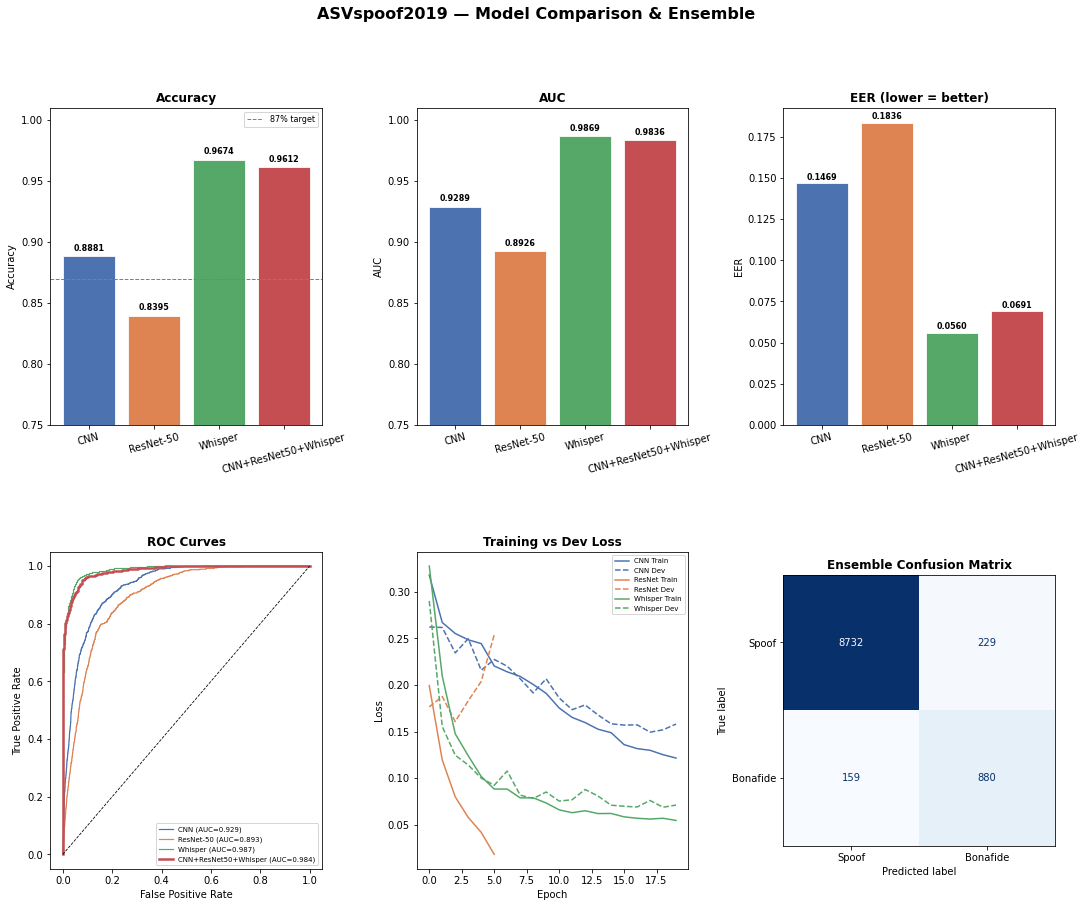

Plot saved as ensemble_results.png ✅


In [14]:
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

# ── Ensemble ───────────────────────────────────────────────────────────
ens_all = (cnn_file_probs + resnet_file_probs + whisper_probs_final) / 3
ens_results = evaluate_all(ens_all, cnn_file_labels, "CNN + ResNet-50 + Whisper")

# ── Data prep ──────────────────────────────────────────────────────────
models = {
    "CNN"                    : (cnn_file_probs,      cnn_file_labels),
    "ResNet-50"              : (resnet_file_probs,   resnet_file_labels),
    "Whisper"                : (whisper_probs_final, whisper_labels_final),
    "CNN+ResNet50+Whisper"   : (ens_all,             cnn_file_labels),
}

names   = list(models.keys())
accs    = [accuracy_score(l, (p>0.5).astype(int)) for p,l in models.values()]
f1s     = [f1_score(l, (p>0.5).astype(int), zero_division=0) for p,l in models.values()]
aucs    = [roc_auc_score(l, p) for p,l in models.values()]
eers    = [compute_eer(l, p)[0] for p,l in models.values()]

colors      = ["#4C72B0", "#DD8452", "#55A868", "#C44E52"]
ens_color   = "#C44E52"

fig = plt.figure(figsize=(18, 14))
fig.suptitle("ASVspoof2019 — Model Comparison & Ensemble", fontsize=16, fontweight="bold", y=0.98)
gs  = gridspec.GridSpec(2, 3, figure=fig, hspace=0.4, wspace=0.35)

# ── 1. Accuracy bar ────────────────────────────────────────────────────
ax1 = fig.add_subplot(gs[0, 0])
bars = ax1.bar(names, accs, color=colors, edgecolor="white", linewidth=0.8)
ax1.axhline(0.87, color="gray", linestyle="--", linewidth=1, label="87% target")
ax1.set_title("Accuracy", fontweight="bold")
ax1.set_ylim(0.75, 1.01)
ax1.set_ylabel("Accuracy")
ax1.tick_params(axis="x", rotation=15)
ax1.legend(fontsize=8)
for bar, val in zip(bars, accs):
    ax1.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.003,
             f"{val:.4f}", ha="center", va="bottom", fontsize=8, fontweight="bold")

# ── 2. AUC bar ─────────────────────────────────────────────────────────
ax2 = fig.add_subplot(gs[0, 1])
bars2 = ax2.bar(names, aucs, color=colors, edgecolor="white", linewidth=0.8)
ax2.set_title("AUC", fontweight="bold")
ax2.set_ylim(0.75, 1.01)
ax2.set_ylabel("AUC")
ax2.tick_params(axis="x", rotation=15)
for bar, val in zip(bars2, aucs):
    ax2.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.003,
             f"{val:.4f}", ha="center", va="bottom", fontsize=8, fontweight="bold")

# ── 3. EER bar ─────────────────────────────────────────────────────────
ax3 = fig.add_subplot(gs[0, 2])
bars3 = ax3.bar(names, eers, color=colors, edgecolor="white", linewidth=0.8)
ax3.set_title("EER (lower = better)", fontweight="bold")
ax3.set_ylabel("EER")
ax3.tick_params(axis="x", rotation=15)
for bar, val in zip(bars3, eers):
    ax3.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.001,
             f"{val:.4f}", ha="center", va="bottom", fontsize=8, fontweight="bold")

# ── 4. ROC curves ──────────────────────────────────────────────────────
ax4 = fig.add_subplot(gs[1, 0])
for (name, (probs, labels)), color in zip(models.items(), colors):
    fpr, tpr, _ = roc_curve(labels, probs)
    auc_val     = roc_auc_score(labels, probs)
    lw          = 2.5 if name == "CNN+ResNet50+Whisper" else 1.2
    ax4.plot(fpr, tpr, color=color, lw=lw, label=f"{name} (AUC={auc_val:.3f})")
ax4.plot([0,1],[0,1], "k--", lw=0.8)
ax4.set_title("ROC Curves", fontweight="bold")
ax4.set_xlabel("False Positive Rate")
ax4.set_ylabel("True Positive Rate")
ax4.legend(fontsize=7)

# ── 5. Training loss curves ────────────────────────────────────────────
ax5 = fig.add_subplot(gs[1, 1])
ax5.plot(cnn_history["train_loss"],     color="#4C72B0", lw=1.5, label="CNN Train")
ax5.plot(cnn_history["dev_loss"],       color="#4C72B0", lw=1.5, linestyle="--", label="CNN Dev")
ax5.plot(resnet_history["train_loss"],  color="#DD8452", lw=1.5, label="ResNet Train")
ax5.plot(resnet_history["dev_loss"],    color="#DD8452", lw=1.5, linestyle="--", label="ResNet Dev")
ax5.plot(whisper_history["train_loss"], color="#55A868", lw=1.5, label="Whisper Train")
ax5.plot(whisper_history["dev_loss"],   color="#55A868", lw=1.5, linestyle="--", label="Whisper Dev")
ax5.set_title("Training vs Dev Loss", fontweight="bold")
ax5.set_xlabel("Epoch")
ax5.set_ylabel("Loss")
ax5.legend(fontsize=7)

# ── 6. Confusion matrix — ensemble only ───────────────────────────────
ax6 = fig.add_subplot(gs[1, 2])
ens_preds = (ens_all > 0.5).astype(int)
cm        = confusion_matrix(cnn_file_labels, ens_preds)
disp      = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=["Spoof", "Bonafide"])
disp.plot(ax=ax6, colorbar=False, cmap="Blues")
ax6.set_title("Ensemble Confusion Matrix", fontweight="bold")

plt.savefig("ensemble_results.png", dpi=150, bbox_inches="tight")
plt.show()
print("Plot saved as ensemble_results.png ✅")

In [15]:
import pickle
from datetime import datetime

save_dir = "saved_models"
os.makedirs(save_dir, exist_ok=True)

# ── Model weights ──────────────────────────────────────────────────────
torch.save(cnn_model.state_dict(),     f"{save_dir}/best_cnn.pth")
torch.save(resnet_model.state_dict(),  f"{save_dir}/best_resnet50.pth")
torch.save(whisper_mlp.state_dict(),   f"{save_dir}/best_whisper_mlp.pth")
print("✅ Model weights saved")

# ── Probabilities ──────────────────────────────────────────────────────
np.save(f"{save_dir}/cnn_file_probs.npy",      cnn_file_probs)
np.save(f"{save_dir}/cnn_file_labels.npy",     cnn_file_labels)
np.save(f"{save_dir}/resnet_file_probs.npy",   resnet_file_probs)
np.save(f"{save_dir}/resnet_file_labels.npy",  resnet_file_labels)
np.save(f"{save_dir}/whisper_probs.npy",       whisper_probs_final)
np.save(f"{save_dir}/whisper_labels.npy",      whisper_labels_final)
np.save(f"{save_dir}/ensemble_probs.npy",      ens_all)
print("✅ Probabilities saved")

# ── Training histories ─────────────────────────────────────────────────
with open(f"{save_dir}/histories.pkl", "wb") as f:
    pickle.dump({
        "cnn"    : cnn_history,
        "resnet" : resnet_history,
        "whisper": whisper_history
    }, f)
print("✅ Training histories saved")

# ── Results summary ────────────────────────────────────────────────────
summary = {
    "timestamp"  : datetime.now().strftime("%Y-%m-%d %H:%M"),
    "CNN"        : cnn_results,
    "ResNet50"   : resnet_results,
    "Whisper"    : whisper_results,
    "Ensemble"   : ens_results,
}
with open(f"{save_dir}/results_summary.pkl", "wb") as f:
    pickle.dump(summary, f)
print("✅ Results summary saved")

# ── Visualization ──────────────────────────────────────────────────────
import shutil
shutil.copy("ensemble_results.png", f"{save_dir}/ensemble_results.png")
print("✅ Visualization saved")

# ── Print summary ──────────────────────────────────────────────────────
print("\n" + "=" * 50)
print("FINAL RESULTS SUMMARY")
print("=" * 50)
print(f"{'Model':<30} {'Acc':>8} {'AUC':>8} {'EER':>8}")
print("-" * 50)
print(f"{'CNN':<30} {cnn_results['accuracy']:>8.4f} {cnn_results['auc']:>8.4f} {cnn_results['eer']:>8.4f}")
print(f"{'ResNet-50':<30} {resnet_results['accuracy']:>8.4f} {resnet_results['auc']:>8.4f} {resnet_results['eer']:>8.4f}")
print(f"{'Whisper MLP':<30} {whisper_results['accuracy']:>8.4f} {whisper_results['auc']:>8.4f} {whisper_results['eer']:>8.4f}")
print(f"{'CNN + ResNet50 + Whisper':<30} {ens_results['accuracy']:>8.4f} {ens_results['auc']:>8.4f} {ens_results['eer']:>8.4f}")
print("=" * 50)
print(f"\nAll files saved to: {save_dir}/")
print(os.listdir(save_dir))

✅ Model weights saved
✅ Probabilities saved
✅ Training histories saved
✅ Results summary saved
✅ Visualization saved

FINAL RESULTS SUMMARY
Model                               Acc      AUC      EER
--------------------------------------------------
CNN                              0.8881   0.9289   0.1469
ResNet-50                        0.8395   0.8926   0.1836
Whisper MLP                      0.9674   0.9869   0.0560
CNN + ResNet50 + Whisper         0.9612   0.9836   0.0691

All files saved to: saved_models/
['whisper_labels.npy', 'best_cnn.pth', 'resnet_file_labels.npy', 'ensemble_results.png', 'results_summary.pkl', 'cnn_file_probs.npy', 'whisper_probs.npy', 'histories.pkl', 'cnn_file_labels.npy', 'resnet_file_probs.npy', 'best_resnet50.pth', 'best_whisper_mlp.pth', 'ensemble_probs.npy']
